# Tree of Thoughts 

Theory

Tree of Thoughts (Yao et al., 2023) frames problem-solving as a search over a tree of reasoning states. Unlike linear CoT, ToT maintains multiple candidate thoughts at each step, evaluates their promise, and uses search algorithms (BFS/DFS/best-first) to explore the thought space.

This mirrors human problem-solving: we consider multiple approaches, evaluate them, backtrack when stuck, and systematically explore alternatives. ToT is especially powerful for tasks requiring exploration — game playing, creative writing, proof construction, and multi-step planning.

In LangGraph, the tree structure is maintained in state as a list of nodes, with a BFS/DFS expansion node, an evaluation node that scores each thought, and a pruning step that keeps only the best branches.


**Problem**: Plan a 3-day trip

**How ToT works here**:
1. `generate_thoughts` — LLM proposes 3 destination ideas
2. `evaluate_thoughts` — LLM scores each on budget, weather, activities
3. `prune_and_select` — Keep only the best-scoring destination
4. `finalize` — LLM builds a full itinerary from the winner

```
problem
  → generate_thoughts   (3 candidates)
  → evaluate_thoughts   (score each)
  → prune_and_select    (keep best)
  → finalize            (full plan)
```

In [1]:
from typing import TypedDict, Optional, Literal
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from IPython.display import Image, display
from dotenv import load_dotenv
import json, os

load_dotenv()
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

llm = ChatOpenAI(model="gpt-4o", temperature=0.7)

In [2]:
# ── State ─────────────────────────────────────────────────
class ToTState(TypedDict):
    problem: str                      # The user's problem
    thoughts: list[dict]              # Generated candidate ideas
    best_thought: Optional[dict]      # Highest-scoring candidate
    best_solution: Optional[str]      # Final developed answer

In [ ]:
# ── Node 1: Generate Thoughts ─────────────────────────────
# Asks the LLM to propose 3 completely different candidate ideas.
# Each idea is one branch of the tree.

def generate_thoughts(state: ToTState) -> ToTState:
    print("[Node 1] Generating 3 candidate thoughts...")

    prompt = f"""Problem: {state['problem']}

Propose exactly 3 DIFFERENT high-level approaches or ideas to solve this.
Each should explore a clearly distinct angle.

Reply with ONLY a JSON list, no markdown fences:
["idea one", "idea two", "idea three"]"""

    response = llm.invoke([HumanMessage(content=prompt)])

    try:
        ideas = json.loads(response.content.strip())
    except json.JSONDecodeError:
        # Fallback: split on newlines if JSON fails
        ideas = [line.strip('- "') for line in response.content.strip().splitlines() if line.strip()]
    ideas = ideas[:3]

    thoughts = [
        {"id": i, "idea": idea, "score": 0.0}
        for i, idea in enumerate(ideas)
    ]

    for t in thoughts:
        print(f"  Thought {t['id']}: {t['idea']}")

    return {**state, "thoughts": thoughts}

    # ✅ Step 1: Try to parse JSON
    # ideas = json.loads(response.content.strip())

    # 👉 It assumes the response looks like this:

    # [
    # "Build a chatbot",
    # "Create a recommendation system",
    # "Develop a fraud detection model"
    # ]
    # Result:
    # ideas = [
    # "Build a chatbot",
    # "Create a recommendation system",
    # "Develop a fraud detection model"
    # ]
    # ❌ Step 2: If JSON fails → fallback logic
    # except json.JSONDecodeError:
    #     ideas = [line.strip('- "') for line in response.content.strip().splitlines() if line.strip()]

    # 👉 This handles messy LLM output like:

    # - Build a chatbot
    # - Create a recommendation system
    # - Develop a fraud detection model
    # What happens here:
    # 1. splitlines()
    # [
    # "- Build a chatbot",
    # "- Create a recommendation system",
    # "- Develop a fraud detection model"
    # ]
    # 2. Clean each line:
    # line.strip('- "')

    # 👉 Removes:

    # -
    # spaces
    # quotes
    # Final result:
    # ideas = [
    # "Build a chatbot",
    # "Create a recommendation system",
    # "Develop a fraud detection model"
    # ]
    # 🔹 Step 3: Take only top 3 ideas
    # ideas = ideas[:3]

    # 👉 Even if you had 10 ideas:

    # ["A", "B", "C", "D", "E"]

    # 👉 It becomes:

    # ["A", "B", "C"]
    # 🔹 Step 4: Convert into structured thoughts
    # thoughts = [
    #     {"id": i, "idea": idea, "score": 0.0}
    #     for i, idea in enumerate(ideas)
    # ]
    # Input:
    # ideas = ["A", "B", "C"]
    # Output:
    # thoughts = [
    # {"id": 0, "idea": "A", "score": 0.0},
    # {"id": 1, "idea": "B", "score": 0.0},
    # {"id": 2, "idea": "C", "score": 0.0}
    # ]

    # 👉 Adds:

    # id → index
    # idea → content
    # score → initialized to 0
    # 🔹 Step 5: Print each thought
    # for t in thoughts:
    #     print(f"  Thought {t['id']}: {t['idea']}")
    # Output:
    # Thought 0: Build a chatbot
    # Thought 1: Create a recommendation system
    # Thought 2: Develop a fraud detection model
    # 🔹 Step 6: Return updated state
    # return {**state, "thoughts": thoughts}

    # 👉 This means:

    # Keep everything in state
    # Add/update "thoughts"
    # Example:
    # state = {
    # "user_input": "Give me project ideas"
    # }
    # Output:
    # {
    # "user_input": "Give me project ideas",
    # "thoughts": [
    #     {"id": 0, "idea": "...", "score": 0.0},
    #     {"id": 1, "idea": "...", "score": 0.0},
    #     {"id": 2, "idea": "...", "score": 0.0}
    # ]
    # }

In [10]:
# ── Node 2: Evaluate Thoughts ─────────────────────────────
# Scores every candidate idea in a single LLM call.
# Returns a score 0.0–1.0 for each thought.

def evaluate_thoughts(state: ToTState) -> ToTState:
    print("\n[Node 2] Evaluating and scoring each thought...")

    ideas_text = "\n".join(
        f"{t['id']}. {t['idea']}" for t in state["thoughts"]
    )
    # 1️⃣ Input: state["thoughts"]

    # Assume this is your data:

    # state["thoughts"] = [
    #     {"id": 0, "idea": "Build a chatbot", "score": 0.0},
    #     {"id": 1, "idea": "Create a recommendation system", "score": 0.0},
    #     {"id": 2, "idea": "Develop a fraud detection model", "score": 0.0}
    # ]
    # 2️⃣ Loop + Format each item
    # f"{t['id']}. {t['idea']}" for t in state["thoughts"]

    # 👉 For each thought t, it creates a string like:

    # 0. Build a chatbot
    # 1. Create a recommendation system
    # 2. Develop a fraud detection model
    # 3️⃣ Join with newline \n
    # "\n".join(...)

    # 👉 Combines all lines into one string separated by new lines

    # 🔹 Final Output
    # ideas_text = """0. Build a chatbot
    # 1. Create a recommendation system
    # 2. Develop a fraud detection model"""

    prompt = f"""Problem: {state['problem']}

Evaluate each idea below. Score each from 0.0 to 1.0 based on:
- Feasibility (can it actually work?)
- Quality (how good is the outcome likely to be?)
- Fit (how well does it match the problem?)

Ideas:
{ideas_text}

Reply with ONLY a JSON object mapping id to score, no markdown fences:
{{"0": 0.7, "1": 0.9, "2": 0.5}}"""

    response = llm.invoke([HumanMessage(content=prompt)])

    try:
        scores = json.loads(response.content.strip())
    except json.JSONDecodeError:
        scores = {str(t["id"]): 0.5 for t in state["thoughts"]}

    scored_thoughts = [
        {**t, "score": float(scores.get(str(t["id"]), 0.5))}
        for t in state["thoughts"]
    ]

    for t in scored_thoughts:
        print(f"  Score {t['score']:.2f} → {t['idea']}")

    return {**state, "thoughts": scored_thoughts}

    # ✅ Step 1: Try to parse scores from response
    # scores = json.loads(response.content.strip())

    # 👉 Expected LLM output:

    # {
    # "0": 0.9,
    # "1": 0.7,
    # "2": 0.4
    # }
    # Result:
    # scores = {
    # "0": 0.9,
    # "1": 0.7,
    # "2": 0.4
    # }
    # ❌ Step 2: If JSON fails → fallback
    # except json.JSONDecodeError:
    #     scores = {str(t["id"]): 0.5 for t in state["thoughts"]}

    # 👉 If LLM gives messy output like:

    # Idea 1 is good
    # Idea 2 is average

    # Then fallback creates:

    # scores = {
    # "0": 0.5,
    # "1": 0.5,
    # "2": 0.5
    # }

    # 👉 Every idea gets a default score = 0.5

    # 🔹 Step 3: Merge scores with thoughts
    # scored_thoughts = [
    #     {**t, "score": float(scores.get(str(t["id"]), 0.5))}
    #     for t in state["thoughts"]
    # ]
    # 🔸 Input thoughts:
    # state["thoughts"] = [
    # {"id": 0, "idea": "Build chatbot"},
    # {"id": 1, "idea": "Recommendation system"},
    # {"id": 2, "idea": "Fraud detection"}
    # ]
    # 🔸 What happens here?

    # For each thought t:

    # Example for id = 0:
    # scores.get("0", 0.5) → 0.9

    # Then:

    # {**t, "score": 0.9}

    # 👉 {**t} means:

    # Copy existing dictionary
    # Add/update "score"
    # 🔸 Final Output:
    # scored_thoughts = [
    # {"id": 0, "idea": "Build chatbot", "score": 0.9},
    # {"id": 1, "idea": "Recommendation system", "score": 0.7},
    # {"id": 2, "idea": "Fraud detection", "score": 0.4}
    # ]
    # 🔹 Step 4: Print results
    # for t in scored_thoughts:
    #     print(f"  Score {t['score']:.2f} → {t['idea']}")
    # Output:
    # Score 0.90 → Build chatbot
    # Score 0.70 → Recommendation system
    # Score 0.40 → Fraud detection

In [11]:
# ── Node 3: Prune and Select ──────────────────────────────
# Sorts all thoughts by score and keeps only the best one.
# This is the "pruning" step — weak branches are discarded.

def prune_and_select(state: ToTState) -> ToTState:
    print("\n[Node 3] Pruning — keeping best thought...")

    best = max(state["thoughts"], key=lambda t: t["score"])
    print(f"  Winner: (score={best['score']:.2f}) {best['idea']}")

    return {**state, "best_thought": best}

In [12]:
# ── Node 4: Finalize ──────────────────────────────────────
# Takes the winning thought and develops it into a full,
# detailed solution. This is the synthesis step.

def finalize(state: ToTState) -> ToTState:
    print("\n[Node 4] Developing the winning thought into a full solution...")

    prompt = f"""Problem: {state['problem']}

The best approach identified is:
{state['best_thought']['idea']}

Now develop this into a complete, detailed, practical solution.
Be specific and actionable."""

    response = llm.invoke([HumanMessage(content=prompt)])
    return {**state, "best_solution": response.content.strip()}

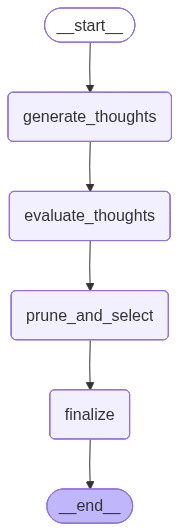

In [7]:
# ── Graph Construction ─────────────────────────────────────
def build_tot_graph():
    builder = StateGraph(ToTState)

    builder.add_node("generate_thoughts", generate_thoughts)
    builder.add_node("evaluate_thoughts", evaluate_thoughts)
    builder.add_node("prune_and_select",  prune_and_select)
    builder.add_node("finalize",          finalize)

    builder.add_edge(START,              "generate_thoughts")
    builder.add_edge("generate_thoughts","evaluate_thoughts")
    builder.add_edge("evaluate_thoughts","prune_and_select")
    builder.add_edge("prune_and_select", "finalize")
    builder.add_edge("finalize",          END)

    return builder.compile()


graph = build_tot_graph()
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
# ── Run: Trip Planning ────────────────────────────────────
result = graph.invoke({
    "problem":      "Plan an exciting 3-day trip for a solo traveller on a medium budget",
    "thoughts":     [],
    "best_thought": None,
    "best_solution":None,
})

print("\n" + "="*60)
print(f"Winning idea: {result['best_thought']['idea']}")
print(f"Score: {result['best_thought']['score']:.2f}")
print("="*60)
print("\nFULL PLAN:")
print(result["best_solution"])

[Node 1] Generating 3 candidate thoughts...
  Thought 0: Plan a city exploration trip focusing on cultural and historical landmarks, including museums, guided tours, and local cuisine experiences.
  Thought 1: Design an adventure-focused trip incorporating outdoor activities such as hiking, kayaking, or zip-lining in a scenic natural location.
  Thought 2: Create a wellness and relaxation retreat itinerary with activities like yoga classes, spa treatments, and meditation sessions in a tranquil environment.

[Node 2] Evaluating and scoring each thought...
  Score 0.90 → Plan a city exploration trip focusing on cultural and historical landmarks, including museums, guided tours, and local cuisine experiences.
  Score 0.80 → Design an adventure-focused trip incorporating outdoor activities such as hiking, kayaking, or zip-lining in a scenic natural location.
  Score 0.70 → Create a wellness and relaxation retreat itinerary with activities like yoga classes, spa treatments, and meditation s

In [9]:
# ── Run: Business Strategy ────────────────────────────────
result2 = graph.invoke({
    "problem":      "Suggest a strategy for a small bakery to increase revenue",
    "thoughts":     [],
    "best_thought": None,
    "best_solution":None,
})

print("\n" + "="*60)
print("All thoughts considered:")
for t in result2["thoughts"]:
    print(f"  {t['score']:.2f}  {t['idea']}")
print(f"\nWinner: {result2['best_thought']['idea']}")
print("="*60)
print(result2["best_solution"])

[Node 1] Generating 3 candidate thoughts...
  Thought 0: Expand the product line to include seasonal and specialty items, such as holiday-themed baked goods or limited-time offerings, to attract new customers and encourage repeat visits.
  Thought 1: Implement a loyalty program that rewards customers with discounts or free items after a certain number of purchases, fostering customer retention and increasing sales frequency.
  Thought 2: Partner with local cafes, restaurants, or grocery stores to supply them with baked goods, thereby expanding the bakery's reach and tapping into new customer bases.

[Node 2] Evaluating and scoring each thought...
  Score 0.80 → Expand the product line to include seasonal and specialty items, such as holiday-themed baked goods or limited-time offerings, to attract new customers and encourage repeat visits.
  Score 0.90 → Implement a loyalty program that rewards customers with discounts or free items after a certain number of purchases, fostering custome

## What each node does

| Node | Job | Key point |
|---|---|---|
| `generate_thoughts` | Proposes 3 distinct candidate ideas | High temp (0.7) for creative diversity |
| `evaluate_thoughts` | Scores all candidates in one call | Batch scoring — no separate LLM call per idea |
| `prune_and_select` | Keeps only the top scorer | Pure Python — no LLM call needed |
| `finalize` | Develops the winner into a full answer | Depth over breadth — one idea, done well |

## ToT vs CoT vs ReAct

| | CoT | ReAct | ToT |
|---|---|---|---|
| Paths explored | 1 | 1 (with tools) | Multiple |
| Backtracking | No | No | Yes (via pruning) |
| External tools | No | Yes | No (here) |
| Best for | Step-by-step logic | Fact-based queries | Creative / planning tasks |